# 03 - Answer quality: does better retrieval produce better answers?

Notebook 02 established a 17-point nDCG gap between BM25 and the dense
retriever. This notebook asks the question that actually matters and that
most RAG writeups skip: **how much of that gap survives into the answers?**

Four conditions, 150 test questions, one variable changed at a time:

| Condition | Passages given to the generator |
|---|---|
| `closed_book` | none -- what the model already knows |
| `rag_bm25` | top-5 from BM25 (nDCG@10 = 0.237) |
| `rag_dense` | top-5 from bge-base (nDCG@10 = 0.406) |
| `oracle` | the human-judged relevant documents |

`closed_book` is the floor RAG has to beat. `oracle` is the ceiling, and it
is what separates a *retrieval* failure from a *generation* failure.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = Path.cwd().parent
report = json.loads((ROOT / "output/reports/generation_metrics.json").read_text())
records = json.loads((ROOT / "data/processed/generation/answers.json").read_text())
judgments = json.loads((ROOT / "data/processed/generation/judgments.json").read_text())

CONDITIONS = ["closed_book", "rag_bm25", "rag_dense", "oracle"]
LABELS = {"closed_book": "No retrieval", "rag_bm25": "RAG (BM25)",
          "rag_dense": "RAG (bge-base)", "oracle": "Oracle (gold)"}
print(f"{report['n_questions']} questions | generator {report['generator_model']} "
      f"| judge {report['judge_model']}")
print(f"evaluation cost: {report['estimated_cost_usd']}")

150 questions | generator claude-opus-5 | judge claude-opus-5
evaluation cost: {'generation': 4.81, 'judging': 8.87}


## 1. Start with the metrics that need no judge

Three of these come from a parser and the human relevance judgments. No
model opinion is involved, so they are the numbers to trust first -- and
they are unaffected by the judge caveat in section 4.

In [2]:
rows = []
for c in CONDITIONS:
    m = report["conditions"][c]
    rows.append({"condition": LABELS[c], "abstained": m.get("abstained"),
                 "citation precision": m.get("citation_precision"),
                 "invalid citations": m.get("invalid_citations")})
pd.DataFrame(rows).set_index("condition")

,abstained,citation precision,invalid citations
condition,,,
No retrieval,NaN,NaN,NaN
RAG (BM25),0.4067,0.1992,0.0
RAG (bge-base),0.1933,0.3029,0.0
Oracle (gold),0.1533,1.0000,0.0


**Abstention tracks retrieval quality.** The system declines to answer far
more often on BM25's weaker passages than on the dense retriever's. That is
the property separating a system that knows what it does not know from one
that confabulates fluently -- and the failure mode of a bad RAG system is
not silence, it is a confident answer wearing citations.

**Citation precision** -- the share of cited passages a human annotator
marked relevant -- moves the same way. The oracle scoring exactly 1.000 is
a pipeline check rather than a finding: by construction every oracle
passage is gold, so anything below 1.0 would mean a bug in the context
builder or the citation parser.

**Zero invalid citations** across 600 answers.

## 2. The judged results, and the surprise

In [3]:
rows = []
for c in CONDITIONS:
    m, v = report["conditions"][c], report["breakdowns"]["verdict_distribution"][c]
    rows.append({"condition": LABELS[c], "correct": m.get("correct"),
                 "correct or partial": m.get("correct_or_partial"),
                 "incorrect": v.get("incorrect", 0.0),
                 "no_answer": v.get("no_answer", 0.0),
                 "grounded": m.get("grounded")})
pd.DataFrame(rows).set_index("condition")

,correct,correct or partial,incorrect,no_answer,grounded
condition,,,,,
No retrieval,0.8200,0.9733,0.0267,0.0000,NaN
RAG (BM25),0.4867,0.6800,0.0333,0.2867,0.9733
RAG (bge-base),0.7133,0.8600,0.0533,0.0867,0.9600
Oracle (gold),0.9267,0.9600,0.0000,0.0400,0.9867


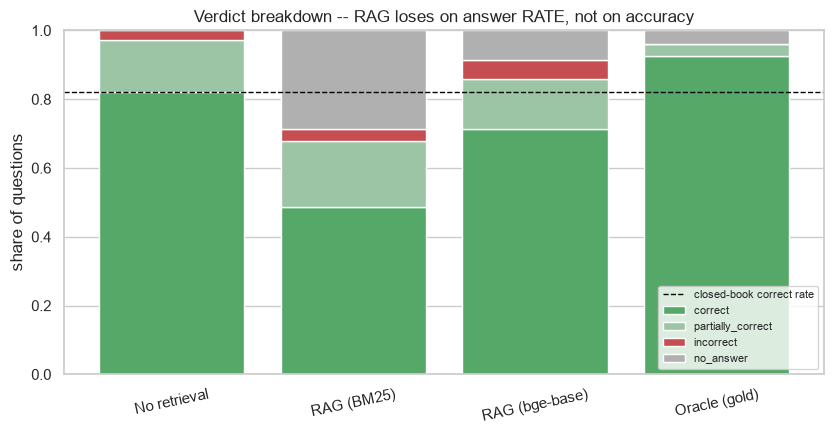

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bottom = np.zeros(len(CONDITIONS))
palette = {"correct": "#55A868", "partially_correct": "#9BC5A5",
           "incorrect": "#C44E52", "no_answer": "#B0B0B0"}
for verdict, color in palette.items():
    vals = np.array([report["breakdowns"]["verdict_distribution"][c].get(verdict, 0.0)
                     for c in CONDITIONS])
    ax.bar([LABELS[c] for c in CONDITIONS], vals, bottom=bottom,
           label=verdict, color=color)
    bottom += vals
ax.axhline(report["conditions"]["closed_book"]["correct"], color="black", ls="--", lw=1,
           label="closed-book correct rate")
ax.set_ylabel("share of questions"); ax.legend(loc="lower right", fontsize=8)
ax.set_title("Verdict breakdown -- RAG loses on answer RATE, not on accuracy")
plt.xticks(rotation=12); plt.tight_layout(); plt.show()

**Retrieval-augmented generation loses to no retrieval at all.**
Closed-book gets 82.0% right; the best RAG configuration gets 71.3%.

That is not the result a demo screenshot would ever surface, and it is
significant, not noise:

In [5]:
mc = report["breakdowns"]["closed_book_vs_rag_dense"]
print("Exact McNemar, paired over the same 150 questions:")
print(f"  closed_book right / rag_dense wrong : {mc['a_only']}")
print(f"  rag_dense right / closed_book wrong : {mc['b_only']}")
print(f"  discordant pairs                    : {mc['discordant']}")
print(f"  two-sided p                         : {mc['p_value']}")

Exact McNemar, paired over the same 150 questions:
  closed_book right / rag_dense wrong : 29
  rag_dense right / closed_book wrong : 13
  discordant pairs                    : 42
  two-sided p                         : 0.01952


Taking that at face value would be the wrong lesson. Three breakdowns say
what is actually happening.

### 2a. RAG's answers are better. It just gives fewer of them.

In [6]:
ga = report["breakdowns"]["given_an_answer"]
pd.DataFrame([{"condition": LABELS[c], "n answered": ga[c]["n"],
               "correct (of those answered)": ga[c]["correct"]}
              for c in CONDITIONS if c in ga]).set_index("condition")

,n answered,correct (of those answered)
condition,,
No retrieval,150,0.8200
RAG (BM25),89,0.7753
RAG (bge-base),121,0.8678
Oracle (gold),127,1.0000


Restricted to questions the system did not abstain on, `rag_dense` is
*more* accurate than closed-book (0.868 vs 0.820), and with the gold
passages it is correct **every single time it speaks** (1.000, n=127).

RAG loses the aggregate purely because abstentions score as not-correct.

### 2b. The abstention is well-targeted, not blanket caution

,n,correct,abstained
retrieval outcome,,,
gold doc retrieved,89,0.9213,0.0562
retrieval missed,61,0.4098,0.3934


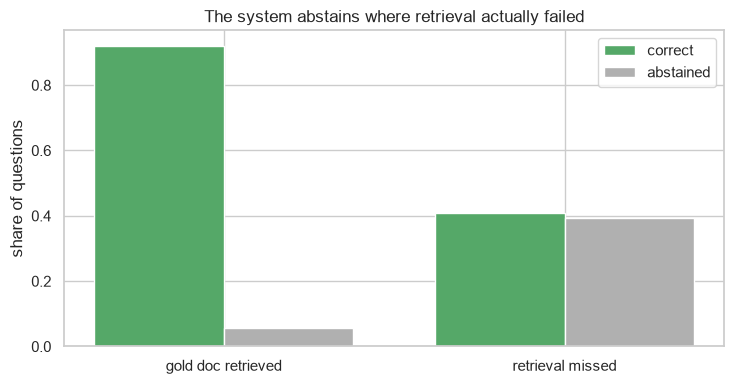

In [7]:
br = report["breakdowns"]["rag_dense_by_retrieval"]
df = pd.DataFrame([{"retrieval outcome": k.replace("_", " "), **v} for k, v in br.items()]
                  ).set_index("retrieval outcome")
display(df)

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(df)); w = 0.38
ax.bar(x - w/2, df["correct"], w, label="correct", color="#55A868")
ax.bar(x + w/2, df["abstained"], w, label="abstained", color="#B0B0B0")
ax.set_xticks(x); ax.set_xticklabels(df.index)
ax.set_ylabel("share of questions")
ax.set_title("The system abstains where retrieval actually failed")
ax.legend(); plt.tight_layout(); plt.show()

The system abstains **seven times more often** when the retriever genuinely
missed (39.3% vs 5.6%), on exactly the questions where abstaining is the
right call. It is detecting its own retrieval failures.

### 2c. The ceiling is retrieval, not generation

Oracle 0.927 against bge-base 0.713. That 21-point gap is entirely
attributable to documents the retriever failed to find -- the same ~20%
complete-miss rate measured in notebook 02. Fix retrieval and the gap
closes; no prompt change will touch it.

### What the trade actually is

The grounding constraint converts retrieval failures into honest
non-answers instead of confident parametric guesses. On this benchmark that
costs 11 points of raw correctness, because the generator already knows
retail personal finance well and the corpus adds little it does not have.
What it buys is verifiability: 96% grounded answers with checkable
citations, against zero citations closed-book.

For a domain the model has memorised, that is a bad deal. For proprietary
documents, post-cutoff facts, or anything that has to be attributable, it
is the entire point. Measuring is how you tell which case you are in.

## 3. Where the answers fail

In [8]:
from src.data.loader import load_split
corpus, queries, qrels = load_split("test")
correct = judgments["judge_correctness"]

rows = []
for key, rec in records.items():
    if rec["condition"] != "rag_dense" or not rec["answer"]:
        continue
    v = (correct.get(key) or {}).get("verdict")
    if not v:
        continue
    rows.append({"gold in context": sum(1 for d in rec["context_ids"]
                                        if d in qrels[rec["qid"]]),
                 "abstained": not rec["answer"]["context_sufficient"],
                 "verdict": v})
df = pd.DataFrame(rows)
pd.crosstab(df["gold in context"] > 0, df["verdict"], normalize="index").round(3)

verdict,correct,incorrect,no_answer,partially_correct
gold in context,,,,
False,0.410,0.131,0.180,0.279
True,0.921,0.000,0.022,0.056


## 4. Can the judge be trusted?

This is the section an LLM-judged evaluation cannot skip. The generator and
the primary judge are both `claude-opus-5`, which makes self-preference a
live risk, and a judge that contradicts itself cannot resolve a small gap.

Two checks were designed. **Only one of them ran.**

In [9]:
cal = report["judge_calibration"]
sc = cal["self_consistency"]
print(f"self-consistency : {sc}")
print(f"cross-model ({cal['cross_model_id']}):")
if "status" in cal["cross_model"]:
    print(f"  status: {cal['cross_model']['status']}")
    print(f"  reason: {cal['cross_model']['reason'][:160]}...")
else:
    print(f"  {cal['cross_model']}")

self-consistency : {'n': 297, 'exact_agreement': 0.9663, 'binary_agreement': 0.9798}
cross-model (claude-haiku-4-5):
  status: not run
  reason: BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthrop...


**Self-consistency: 96.6%** exact verdict agreement over 297 re-judged
items (98.0% on the correct / not-correct collapse). The judge is precise
enough to resolve the 11-point gap carrying the headline finding -- a judge
that disagreed with itself 20% of the time could not.

**The cross-model check did not run.** The API credit balance was exhausted
before its batch was submitted, and it is recorded as `"status": "not run"`
rather than quietly dropped. Until it runs, **every judged number here is
un-cross-validated**: a judge favouring its own family's output would
inflate all four conditions, and nothing measured here rules that out.

The section 1 metrics -- abstention, citation precision, invalid citations
-- involve no model opinion and are unaffected. So is the *direction* of
the headline finding to the extent it rests on abstention counts, which are
mechanical.

## 5. Read some actual answers

Percentages are not inspectable. Three answers per verdict, including the
ones the judge called incorrect, are committed so its calls can be
checked.

In [10]:
samples = json.loads((ROOT / "output/reports/answer_samples.json").read_text())
for verdict in ("incorrect", "no_answer"):
    for ex in samples.get(verdict, [])[:1]:
        print(f"--- judged {verdict} | condition={ex['condition']} | "
              f"gold passages in context={ex['gold_passages_in_context']} ---")
        print(f"Q: {ex['question'][:160]}")
        print(f"A: {ex['answer'][:320]}")
        print(f"judge: {ex['judge_correctness_reason'][:220]}\n")

--- judged incorrect | condition=rag_dense | gold passages in context=0 ---
Q: 401k Transfer After Business Closure
A: The passages only partly touch on this. They confirm that in a defined-contribution plan (401k, 403b, 457, TSP) the employer must turn over withheld contributions and any match to the plan trustee within days or weeks, so once the money reaches the trustee it is beyond the company's reach even if the business folds or 
judge: The candidate discusses unrelated points (timing of employer deposits to the trustee, 401k loan repayment on separation) and explicitly says it cannot explain the rollover/termination process, missing the reference's key

--- judged no_answer | condition=rag_bm25 | gold passages in context=0 ---
Q: A-B-C Class Shares: What's the difference?
A: The passages don't actually explain what distinguishes Class A, B and C shares. They only give fragments: Google issued Class C shares to Class A (GOOG) holders in 2014, with tickers shifting so Class C beca